<a href="https://colab.research.google.com/github/opinner/thesis_introductory_figures/blob/main/C02_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# CO2 Time Series
 data from X. Lan and R. Keeling, ‘Trends in Atmospheric Carbon Dioxide (CO2)’. Sep. 05, 2025.  
 Available: https://gml.noaa.gov/ccgg/trends/data.html


In [140]:
co2 = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv", parse_dates=True, comment='#')
co2["day"]=15 # put timestamp in the middle of the month
co2["date"] = pd.to_datetime(co2[["year", "month", "day"]])
co2 = co2.set_index(co2["date"])
co2

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc,day,date
date,,,,,,,,,,
1958-03-15,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99,15,1958-03-15
1958-04-15,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99,15,1958-04-15
1958-05-15,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99,15,1958-05-15
1958-06-15,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99,15,1958-06-15
1958-07-15,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99,15,1958-07-15
...,...,...,...,...,...,...,...,...,...,...
2025-04-15,2025,4,2025.2917,429.64,427.13,23,0.73,0.29,15,2025-04-15
2025-05-15,2025,5,2025.3750,430.51,427.26,23,0.39,0.16,15,2025-05-15
2025-06-15,2025,6,2025.4583,429.61,427.16,26,0.71,0.27,15,2025-06-15


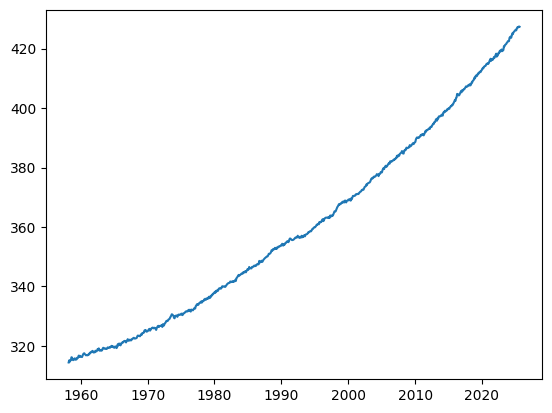

In [141]:
plt.plot(co2["date"],co2["deseasonalized"])

# Polital Events Time Series

In [142]:
events_data = [
    {"event": "First World Climate Conference", "date": "1979-02-12", "label": "First World\nClimate Conference", "xyshift":(0, 20)},
    {"event": "First IPCC Report", "date": "1990-08-01", "label":"First IPCC Report", "xyshift":(0, 20)},
    {"event": "First UN Climate Change Conference (COP1)", "date": "1995-03-28", "label": "First UN Climate Change Conference", "xyshift":(0, 25)},
    {"event": "Kyoto Protocol adopted", "date": "1997-12-11", "label":"Kyoto Protocol adopted", "xyshift":(0, 39)},
    {"event": "Kyoto Protocol beginning", "date": "2005-02-16", "label":"Kyoto Protocol beginning", "xyshift":(0, 36)},
    {"event": "Copenhagen Accord", "date": "2009-12-18", "label":"Copenhagen Accord", "xyshift":(0, 45)},
    #{"event": "Paris Agreement adoption", "date": "2015-12-12", "label":"Paris Agreement\nadoption", "xyshift":},
    {"event": "Paris Agreement beginning", "date": "2016-11-04", "label":"Paris Agreement", "xyshift":(0, 30)},
    {"event": "IPCC Sixth Assessment Report Synthesis Report Release", "date": "2023-03-20", "label":"6th IPCC Synthesis Report", "xyshift":(0, 25)}
]

events = pd.DataFrame(events_data)
events['date'] = pd.to_datetime(events['date']) #convert to time stamp

# simplify date to middle of the month
from pandas.tseries.offsets import DateOffset
simplified_dates = events['date'].dt.to_period('M').dt.to_timestamp() + DateOffset(days=14)

# add co2 value around that time
events["co2"] = co2["deseasonalized"].loc[simplified_dates].values
events

,event,date,label,xyshift,co2
0,First World Climate Conference,1979-02-12,First World\nClimate Conference,"(0, 20)",336.00
1,First IPCC Report,1990-08-01,First IPCC Report,"(0, 20)",354.68
2,First UN Climate Change Conference (COP1),1995-03-28,First UN Climate Change Conference,"(0, 25)",360.37
3,Kyoto Protocol adopted,1997-12-11,Kyoto Protocol adopted,"(0, 39)",365.28
4,Kyoto Protocol beginning,2005-02-16,Kyoto Protocol beginning,"(0, 36)",379.10
5,Copenhagen Accord,2009-12-18,Copenhagen Accord,"(0, 45)",388.43
6,Paris Agreement beginning,2016-11-04,Paris Agreement,"(0, 30)",405.74
7,IPCC Sixth Assessment Report Synthesis Report ...,2023-03-20,6th IPCC Synthesis Report,"(0, 25)",419.53


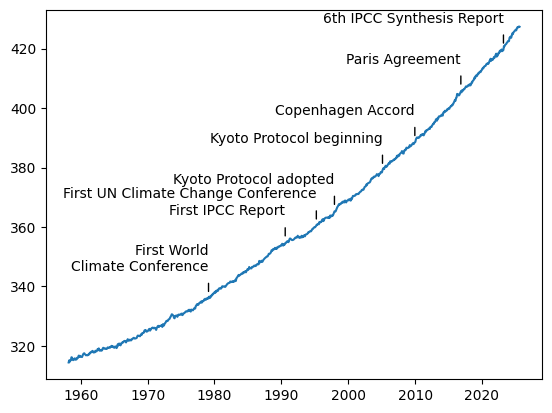

In [143]:
plt.plot(co2["date"],co2["deseasonalized"])

for date, co2_level, label in events[["date","co2","label"]].values:
    plt.annotate(label,
                xy=(date, co2_level), xycoords='data',
                xytext=(0, 20), textcoords='offset points',
                ha="right",
                arrowprops=dict(arrowstyle="-", facecolor='black', shrinkA=5, shrinkB=5, relpos=(1,0))
                )

# Warming Stripes
image from E. Hawkins, ‘Global Warming Stripes 	1850–2024’. 2024.   Available: https://showyourstripes.info/


In [144]:
!wget https://showyourstripes.info/stripes/GLOBE---1850-2024-MO.png -O climate_stripes.png

--2025-10-13 19:42:27--  https://showyourstripes.info/stripes/GLOBE---1850-2024-MO.png
Resolving showyourstripes.info (showyourstripes.info)... 104.21.39.254, 172.67.172.214, 2606:4700:3032::ac43:acd6, ...
Connecting to showyourstripes.info (showyourstripes.info)|104.21.39.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29075 (28K) [image/png]
Saving to: ‘climate_stripes.png’

climate_stripes.png 100%[===================>]  28.39K  --.-KB/s    in 0s      

2025-10-13 19:42:27 (97.8 MB/s) - ‘climate_stripes.png’ saved [29075/29075]



In [145]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [146]:
from PIL import Image

# Load image
image = Image.open('climate_stripes.png')
# Convert image to array
image_arr = np.array(image)

left_year = co2["date"].iloc[0].year #1958
number_of_stripes = 2024-1850
pixel_per_year = np.shape(image_arr)[1] / number_of_stripes
left = int((left_year-1850)*pixel_per_year) -16 # 16 pixel is is hardcoded, as I made an error somewhere

# Crop image
image_1958_2024 = image_arr[0:100,left:,:]

(1958.0, 2025.0)

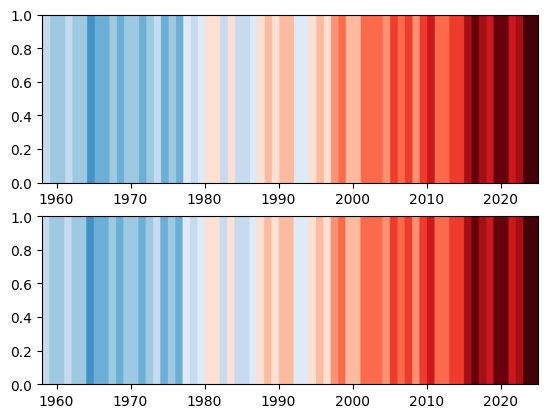

In [147]:
fig, (ax1,ax2) = plt.subplots(nrows=2) #, figsize=(25,5))
ax1.imshow(image_1958_2024, extent=(1958, 2025, 0, 1), aspect="auto")
#plt.gca().set_xticks(np.arange(left_year, right_year, 5));
#ax1.set_xlim(1955,1960)

ax2.imshow(image_arr, extent=(1850, 2025, 0, 1), aspect="auto")
ax2.set_xlim(1958,2025)

# Final Image

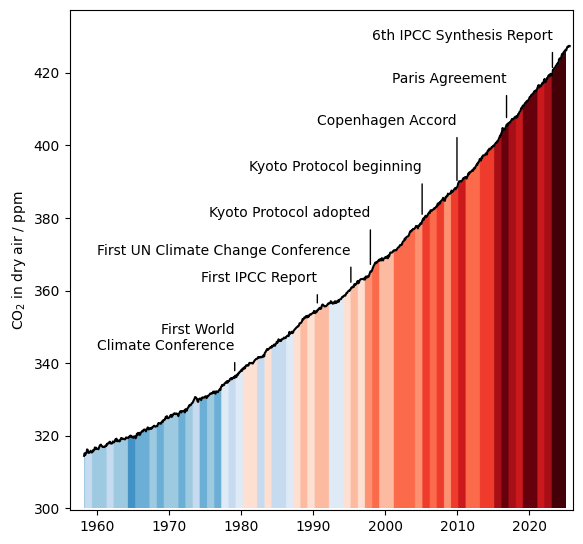

In [148]:
fig, ax = plt.subplots(1, figsize=(6.5,6.5))

ax.imshow(image_1958_2024, extent=(co2["date"].iloc[0], pd.to_datetime("2025-01-15"), 300, co2["deseasonalized"].iloc[-1]), aspect="auto")

ax.fill_between(
    x=co2["date"],
    y1=co2["deseasonalized"],
    y2=600, #co2["deseasonalized"].iloc[-1],
    color="white"
  )

ax.plot(co2["date"],co2["deseasonalized"],"k")

#xyshifts = ((0, 20),) * len(events["date"])
for date, co2_level, label, xyshift in events[["date","co2","label","xyshift"]].values:
    ax.annotate(
        label,
        xy=(date, co2_level), xycoords='data',
        xytext=xyshift, textcoords='offset points',
        ha="right",
        # bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="lightgrey", lw=1),
        arrowprops=dict(arrowstyle="-", facecolor='black', shrinkA=5, shrinkB=5, relpos=(1,0))
    )

ax.set_xlim(pd.to_datetime("1956-3-15"),pd.to_datetime("2026-2-15"))
ax.set_ylim(co2["deseasonalized"].iloc[0]-15,co2["deseasonalized"].iloc[-1]+10)

ax.set_ylabel("CO$_2$ in dry air / ppm")

fig.savefig("CO2Stripes.pdf",bbox_inches="tight")